# Convolving EMIT to Cubert Ultris VNIR spectral sampling

This tutorial takes a real **EMIT L2A reflectance scene** and convolves it to
the **Cubert Ultris VNIR** band centers using `srfforge`. The result shows what
a co-located Ultris sensor would have measured over the same area.

This is useful for:
- Comparing airborne Ultris measurements against EMIT satellite observations
- Understanding which features are resolvable at Ultris vs EMIT spectral sampling
- Cross-sensor validation workflows

| | EMIT (source) | Cubert Ultris VNIR (target) |
|---|---|---|
| Range | 366–2500 nm | 350–1002 nm |
| Bands | 288 good | 164 |
| Sampling | ~8.4–8.8 nm Gaussian | 4 nm uniform |
| FWHM | 8.4–8.8 nm | ~8 nm (verify with calibration) |

> **Note:** EMIT only covers 366–2500 nm, so Ultris bands below 366 nm
> (bands 1–4, 350–362 nm) will have near-zero weights and should be masked.

---
## 1. Setup

### Option A — conda (recommended)
```bash
conda env create -f environment.yml
conda activate srfforge
```

### Option B — pip
```bash
pip install -e ".[full]"
```

### NASA Earthdata account
Register at https://urs.earthdata.nasa.gov/users/new (free).

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

import earthaccess
import xarray as xr

from srfforge import BandConvolver, EMIT, CubertUltris
from srfforge.plot import compare_spectra, rgb_quicklook


In [2]:
auth = earthaccess.login(persist=True)
print("Authenticated:", auth.authenticated)

Authenticated: True


---
## 2. Download an EMIT L2A scene

In [7]:
# Angeles NF, CA — same area as the AVIRIS-3 tutorial
BBOX = (-118.5, 34.0, -117.5, 34.8)

emit_results = earthaccess.search_data(
    short_name="EMITL2ARFL",
    version="001",
    bounding_box=BBOX,
    temporal=("2024-08-01", "2024-09-30"),
    count=10,
)
print(f"EMIT granules found: {len(emit_results)}")
for g in emit_results:
    print(f"  {g['umm']['GranuleUR']}  "
          f"{g['umm']['TemporalExtent']['RangeDateTime']['BeginningDateTime'][:10]}")

EMIT granules found: 2
  EMIT_L2A_RFL_001_20240825T173104_2423811_007  2024-08-25
  EMIT_L2A_RFL_001_20240825T173115_2423811_008  2024-08-25


/opt/miniconda3/envs/srfforge/lib/python3.11/site-packages/earthaccess/results.py:343: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


In [8]:
data_dir = Path("data")
data_dir.mkdir(exist_ok=True)

chosen = emit_results[0]
print(f"Downloading: {chosen['umm']['GranuleUR']}")

emit_files = earthaccess.download([chosen], local_path=data_dir)

# Pick the reflectance file; skip the uncertainty and mask ancillary files
emit_nc = next(
    Path(f) for f in emit_files
    if "RFL" in Path(f).name
    and "UNCERT" not in Path(f).name
    and Path(f).suffix in (".nc", ".nc4")
)
print(f"\nFile: {emit_nc.name}  ({emit_nc.stat().st_size / 1e6:.0f} MB)")

Downloading: EMIT_L2A_RFL_001_20240825T173104_2423811_007


/opt/miniconda3/envs/srfforge/lib/python3.11/site-packages/earthaccess/store.py:832: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum(granule.size() for granule in granules) / 1024, 2)


QUEUEING TASKS | :   0%|          | 0/3 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/3 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/3 [00:00<?, ?it/s]


File: EMIT_L2A_RFL_001_20240825T173104_2423811_007.nc  (1851 MB)


---
## 3. Read the EMIT scene

In [9]:
ds_refl  = xr.open_dataset(emit_nc, engine="netcdf4")
ds_bands = xr.open_dataset(emit_nc, engine="netcdf4", group="sensor_band_parameters")

emit_refl  = ds_refl["reflectance"].values.astype(np.float32)   # (lines, samples, bands)
emit_wl    = ds_bands["wavelengths"].values                       # nm, all bands
good_bands = ds_bands["good_wavelengths"].values.astype(bool)    # True = usable band

# Replace fill values with NaN
fill = ds_refl["reflectance"].attrs.get("_FillValue", -9999.0)
emit_refl[emit_refl == fill] = np.nan

rows, cols, n_bands = emit_refl.shape
print(f"EMIT scene shape : {rows} × {cols} pixels, {n_bands} bands")
print(f"Wavelength range : {emit_wl[0]:.1f} – {emit_wl[-1]:.1f} nm")
print(f"Good bands       : {good_bands.sum()} / {n_bands}  (bad = water-vapour absorption)")
print(f"Valid pixels     : {np.isfinite(emit_refl[:, :, 0]).mean():.1%}")

EMIT scene shape : 1280 × 1242 pixels, 285 bands
Wavelength range : 381.0 – 2492.9 nm
Good bands       : 244 / 285  (bad = water-vapour absorption)
Valid pixels     : 100.0%


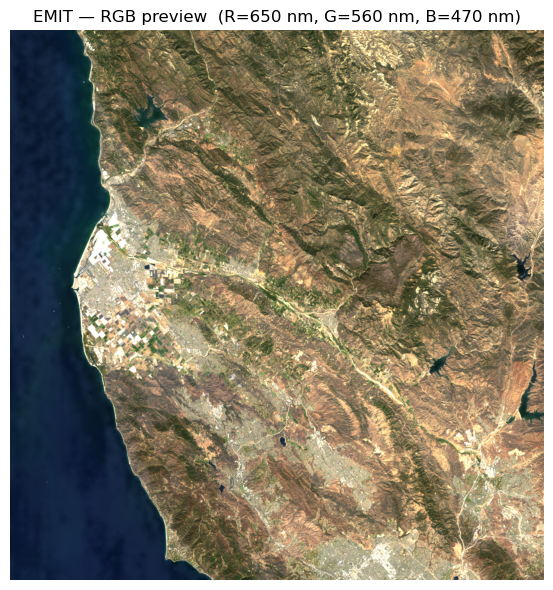

In [10]:
def _band_idx(wl_array, target_nm):
    return int(np.argmin(np.abs(wl_array - target_nm)))

r_idx = _band_idx(emit_wl, 650)
g_idx = _band_idx(emit_wl, 560)
b_idx = _band_idx(emit_wl, 470)

rgb_preview = emit_refl[:, :, [r_idx, g_idx, b_idx]]
rgb_preview = np.clip(rgb_preview / np.nanpercentile(rgb_preview, 98), 0, 1)
rgb_preview = np.where(np.isnan(rgb_preview), 1.0, rgb_preview)

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(rgb_preview)
ax.set_title("EMIT — RGB preview  (R=650 nm, G=560 nm, B=470 nm)")
ax.axis("off")
plt.tight_layout()
plt.show()

---
## 4. Set up instruments and convolver

We use the per-acquisition EMIT wavelengths from the product file (more accurate
than the bundled nominal values), then build `BandConvolver(source=emit, target=ultris)`.

In [11]:
emit   = EMIT(srf_file=str(emit_nc))   # per-acquisition wavelengths
ultris = CubertUltris(fwhm_nm=8.0)    # 164 bands, 350–1002 nm

print(emit)
print(ultris)

# Ultris bands that are well-covered by EMIT (both sides within EMIT range)
ultris_in_emit = (
    (ultris.wavelengths >= emit.wavelengths[0] + ultris.fwhm) &
    (ultris.wavelengths <= emit.wavelengths[-1])
)
print(f"\nUltris bands covered by EMIT : {ultris_in_emit.sum()}  "
      f"({ultris.wavelengths[ultris_in_emit][0]:.0f}–{ultris.wavelengths[ultris_in_emit][-1]:.0f} nm)")
print(f"Ultris bands below EMIT range: {(~ultris_in_emit).sum()}  "
      f"(350–{ultris.wavelengths[~ultris_in_emit][-1]:.0f} nm — will be zero)")

EMIT(n_bands=285, range=381.0–2492.9 nm)
CubertUltris(n_bands=164, range=350.0–1002.0 nm)

Ultris bands covered by EMIT : 154  (390–1002 nm)
Ultris bands below EMIT range: 10  (350–386 nm — will be zero)


In [12]:
conv = BandConvolver(source=emit, target=ultris)
print(f"Convolution matrix : {conv.matrix.shape}  (Ultris bands × EMIT bands)")
print(f"Row sums — well-covered bands (should be ~1.0):")
print(f"  min={conv.matrix[ultris_in_emit].sum(axis=1).min():.3f}  "
      f"max={conv.matrix[ultris_in_emit].sum(axis=1).max():.3f}")

Convolution matrix : (164, 285)  (Ultris bands × EMIT bands)
Row sums — well-covered bands (should be ~1.0):
  min=1.000  max=1.000


---
## 5. Convolve EMIT → Ultris

The full scene convolution is a single matrix multiply over all pixels.
Output shape is `(lines, samples, 164)` — one value per Ultris band per pixel.

In [13]:
# NaN pixels (fill-value / scene edges) would propagate through the matrix multiply.
# Replace them with 0 first, apply the convolution, then restore NaN so downstream
# code can mask them correctly.
nan_mask   = np.isnan(emit_refl).any(axis=-1)              # (lines, samples)
refl_clean = np.where(np.isnan(emit_refl), 0.0, emit_refl)

emit_as_ultris = conv(refl_clean).astype(np.float32)       # (lines, samples, 164)
emit_as_ultris[nan_mask] = np.nan

print(f"EMIT original      : {emit_refl.shape}")
print(f"Convolved to Ultris: {emit_as_ultris.shape}")

EMIT original      : (1280, 1242, 285)
Convolved to Ultris: (1280, 1242, 164)


---
## 6. Visualise

### 6a. Spectral comparison — EMIT vs convolved to Ultris

/var/folders/4y/vdf6lk8d18qf_nvdqb40_nfw0000gn/T/ipykernel_15581/3031934982.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


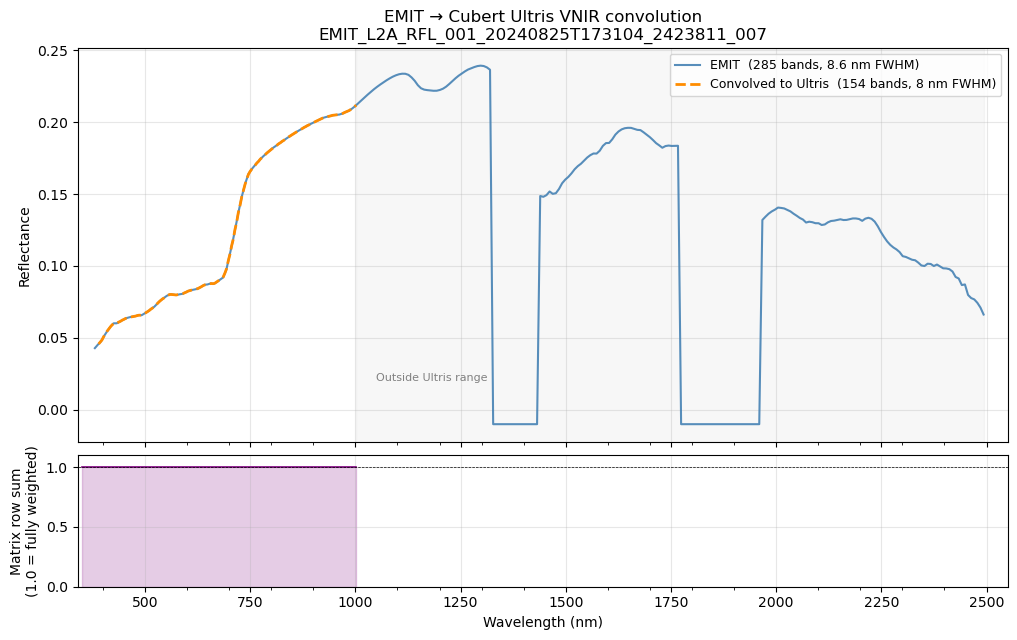

Saved: emit_to_ultris_spectra.png


In [14]:
# Sample valid pixels for mean spectra
src_flat = emit_refl.reshape(-1, emit_refl.shape[-1])
tgt_flat = emit_as_ultris.reshape(-1, emit_as_ultris.shape[-1])
valid = np.isfinite(src_flat).all(axis=1)
idx = np.random.default_rng(0).choice(np.where(valid)[0], size=min(500, valid.sum()), replace=False)

emit_mean   = src_flat[idx].mean(axis=0)
ultris_mean = tgt_flat[idx].mean(axis=0)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                          gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05})

# Full EMIT spectrum
axes[0].plot(emit.wavelengths, emit_mean, lw=1.5, color="steelblue", alpha=0.9,
             label=f"EMIT  ({len(emit.wavelengths)} bands, {emit.fwhm.mean():.1f} nm FWHM)")

# Convolved to Ultris — only show well-covered bands
axes[0].plot(ultris.wavelengths[ultris_in_emit], ultris_mean[ultris_in_emit],
             lw=2, ls="--", color="darkorange",
             label=f"Convolved to Ultris  ({ultris_in_emit.sum()} bands, {ultris.fwhm.mean():.0f} nm FWHM)")

axes[0].axvspan(ultris.wavelengths[-1], emit.wavelengths[-1],
                alpha=0.06, color="gray")
axes[0].text(1050, 0.02, "Outside Ultris range", fontsize=8, color="gray")
axes[0].set_ylabel("Reflectance")
axes[0].set_title(
    f"EMIT → Cubert Ultris VNIR convolution\n"
    f"{chosen['umm']['GranuleUR']}"
)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Row sums — show convolution weight coverage
row_sums = conv.matrix.sum(axis=1)
axes[1].plot(ultris.wavelengths, row_sums, lw=1.2, color="purple")
axes[1].fill_between(ultris.wavelengths, 0, row_sums, alpha=0.2, color="purple")
axes[1].axhline(1.0, color="k", lw=0.5, ls="--")
axes[1].set_ylabel("Matrix row sum\n(1.0 = fully weighted)")
axes[1].set_xlabel("Wavelength (nm)")
axes[1].set_ylim(0, 1.1)
axes[1].grid(True, alpha=0.3)

for ax in axes:
    ax.set_xlim(340, 2550)
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(100))

plt.tight_layout()
plt.savefig(data_dir / "emit_to_ultris_spectra.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: emit_to_ultris_spectra.png")

### 6b. RGB quicklooks

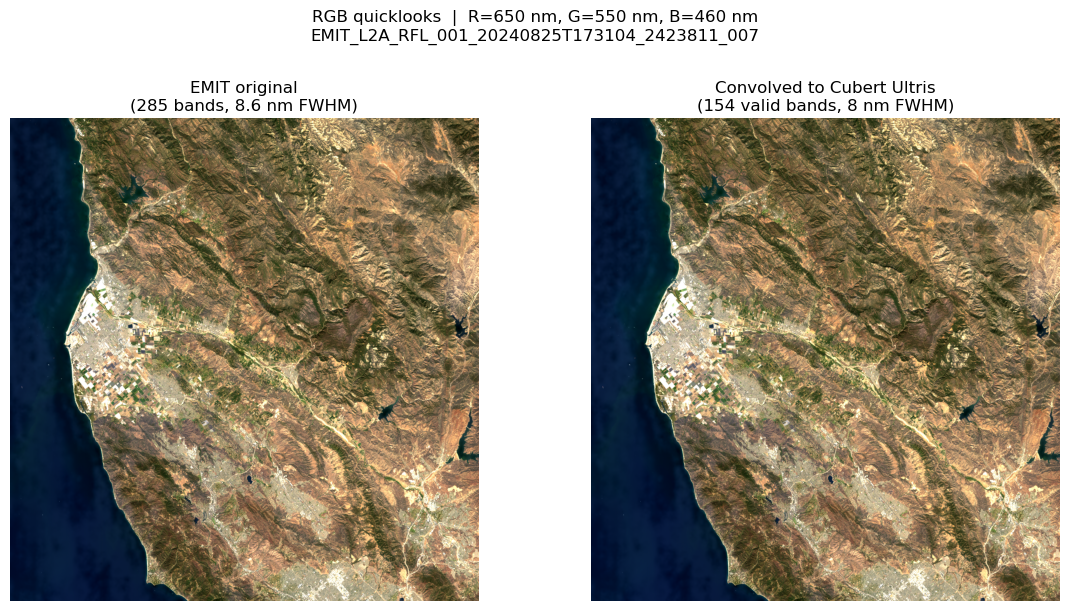

Saved: emit_to_ultris_rgb.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

rgb_quicklook(emit_refl,     instrument=emit,   ax=axes[0])
rgb_quicklook(emit_as_ultris, instrument=ultris, ax=axes[1])

axes[0].set_title(
    f"EMIT original\n({len(emit.wavelengths)} bands, {emit.fwhm.mean():.1f} nm FWHM)"
)
axes[1].set_title(
    f"Convolved to Cubert Ultris\n({ultris_in_emit.sum()} valid bands, {ultris.fwhm.mean():.0f} nm FWHM)"
)
fig.suptitle(
    "RGB quicklooks  |  R=650 nm, G=550 nm, B=460 nm\n"
    f"{chosen['umm']['GranuleUR']}",
    y=1.01,
)
fig.tight_layout()
fig.savefig(data_dir / "emit_to_ultris_rgb.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: emit_to_ultris_rgb.png")